# **Car Price Prediction with Machine Learning**

---
Done by:<br>
ANAS A A KHAMAYSA<br>
ABDALHAMID ALBEIK<br>
ABDALJAWWAD M. A. TARADEH<br>
ABDULRAHMAN Maeen Qaid ALHABBARI<br>

Car price prediction is an important application of machine learning in both finance and marketing domains. The price of a car is influenced by multiple factors such as brand, model, mileage, horsepower, and additional features.

In this project, we aim to build a machine learning model that can accurately predict the price of a car based on its attributes. This problem is considered a supervised learning task, specifically a regression problem, where the goal is to estimate a continuous value.

Understanding the factors that affect car prices can help buyers make better decisions and assist sellers in setting competitive prices. Therefore, developing an accurate prediction model has practical value in real-world applications.

---

### The project's flow is:


1.   Import Libraries
2.   Load Data
3.   Data Cleaning
5.   Feature Engineering
6.   Preprocessing (Encoding & Scaling)
7.   Train/Test Split
8.   Model Training (Linear Regression, Random Forest, XGBoost)
9.   Evaluation (MAE, RMSE, R²)
10.  Visualization (Actual vs Predicted & Model Comparison)
11.  Examples

## Data Description 📊

The dataset used in this project was obtained from [Kaggle](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset) and contains detailed information about used cars and their characteristics. It is designed to analyze the factors affecting car prices and to build a machine learning model for price prediction.

### Dataset Structure 🔢
The dataset contains:

*   4009 rows (cars) ✅
*   12 columns (features) ✅

Each row represents a single car with its specifications.

### Important Features 📌

The dataset includes the following key features:

*   `brand`: Car manufacturer (e.g., Ford, Hyundai, Lexus)
*   `model`: Specific model of the car
*   `model_year`: Year of manufacture
*   `milage`: Distance driven by the car
*   `fuel_type`: Type of fuel (Gasoline, Hybrid, etc.)
*   `engine`: Engine specifications (text-based)
*   `transmission`: Type of transmission
*   `ext_col` / int_col: Exterior and interior colors
*   `accident`: Accident history
*   `clean_title`: Indicates whether the car has a clean title

### Target Variable 🎯

*   `price`: The variable that the model aims to predict.

### Data Types 📊



*   Categorical Features: brand, model, fuel_type, transmission, colors, accident, clean_title
*   Numerical Features: model_year, mileage (after preprocessing)
*   Mixed/Text Features: engine (requires feature extraction)

### Problem Type 💡

This dataset is used to solve a supervised machine learning regression problem, where the goal is to predict a continuous value (car price).

### Data Challenges ⚠️

Some features require preprocessing:



*   Mileage values include units (e.g., "mi.")
*   Price includes symbols (e.g., "$")
*   Engine data is in text format

---

In [ ]:
# You can run this code when you want to connect the code with the Google Drive
# account to reach the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🔹 Step 1: Import Libraries

In this step, we imported the essential Python libraries required for data analysis and machine learning. The `pandas` library is used for data manipulation and handling tabular data, while `numpy` is used for numerical computations. Additionally, `matplotlib` and `seaborn` are used for data visualization.

This step is important because these libraries provide the necessary tools to load, explore, and analyze the dataset efficiently.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

---



## 🔹 Step 2: Load the Dataset

In [ ]:
# Read the Dataset from Google Drive to df variable
df = pd.read_csv("/content/drive/MyDrive/Cars_Data.csv") # Loading the dataset

In this step, the dataset was loaded from a CSV file using the `read_csv()` function from the `pandas` library. The dataset was stored in a variable named `df`, which will be used throughout the project.

Loading the dataset is the first step in any data analysis process, as it allows us to access and manipulate the data.

## 🔹 Step 3: Display Basic Information

This step helps us understand the structure of the dataset and verify that the data has been loaded correctly.

In [ ]:
# shows the number of rows and columns
print("Shape of dataset:", df.shape)

# lists all column names
print("\nColumn names:")
print(df.columns)

# displays the first 5 rows
print("\nFirst 5 rows:")
print(df.head())

# displays the last 5 rows
print("\nLast 5 rows:")
print(df.tail())

Shape of dataset: (4009, 12)

Column names:
Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

First 5 rows:
      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinde

## 🔹 Step 4: Check Data Types

The `info()` function provides detailed information about the dataset, including:


*   Data types of each column
*   Number of non-null values
*   Memory usage

This step helps identify whether the data is numerical or categorical and detect any missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## 🔹 Step 5: Check Missing Values

Handling missing values is essential before training any machine learning model, as they can negatively affect performance.

In [ ]:
# checks for missing values in each column by counting how many null values exist.
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


## 🔹 Step 6: Statistical Summary

This step provides insights into the distribution of numerical data and helps identify potential outliers.

Missing values appear because the original data is non-numeric. This issue will be addressed in a later step.

In [ ]:
# Generates statistical summaries for numerical columns
# including: Mean, Standard deviation, Minimum and maximum values, Quartiles
# (include='all') Display all columns (including text)
df.describe(include='all')


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In this stage, the dataset was successfully loaded and explored using several `pandas` functions. Basic information such as the dataset shape, column names, sample records, data types, and missing values were examined. This initial exploration helped in understanding the dataset structure and identifying potential issues that need to be addressed during preprocessing.

## Preprocessing, Data Cleaning and Feature Engineering

---



## 🔹 Step 7: Make a Copy of the Dataset

In this step, we created a copy of the original dataset and stored it in a new variable called `df_clean`. This is a good practice because it allows us to preprocess the data without changing the original dataset.

Creating a copy helps preserve the raw data in case we need to go back and review the original values later.

In [ ]:
# Copy the Dataset into df_clean
df_clean = df.copy()

## 🔹 Step 8: Clean the `price` Column

The `price` column contains special characters such as the dollar sign `$` and commas `,`, which prevent it from being treated as a numeric variable. In this step, these characters were removed using regular expressions, and then the column was converted to numeric format.

This step is necessary because the target variable must be numeric before training any regression model.

In [ ]:
# In price column replace $ and , with (nothing) to be a pure number
# (regex=True) To tell Pandas that the text we wrote is a Regex
df_clean["price"] = df_clean["price"].replace(r'[\$,]', '', regex=True)

# Convert the "price" column to numerical values ​​(numbers) instead of text.
# (errors="coerce") If the value is convertible, it is converted to a number
# if not (for example, strange text), it is converted to NaN.
df_clean["price"] = pd.to_numeric(df_clean["price"], errors="coerce")

## 🔹 Step 9: Clean the `milage` Column

The `milage` column includes text such as `mi.` and commas, which means it is stored as text rather than numbers. In this step, these extra characters were removed, and the values were converted into numeric format.

`Mileage` is an important numerical feature in car price prediction, so it must be converted into a proper numeric form before model training.

In [ ]:
# (regex=False) To tell Pandas that the text we wrote is a Regular Text
df_clean["milage"] = df_clean["milage"].str.replace(" mi.", "", regex=False)
df_clean["milage"] = df_clean["milage"].str.replace(",", "", regex=False)
df_clean["milage"] = pd.to_numeric(df_clean["milage"], errors="coerce")

## 🔹 Step 10: Edit and Creating New Features

### 1.   Create Car Age

A new feature called `car_age` was created by subtracting the manufacturing year from the current year.

Car age is more meaningful than the raw year and helps improve prediction accuracy.

In [ ]:
# import datetime function
from datetime import datetime

# Load current year
current_year = datetime.now().year

# Add new column (feature)
df_clean["car_age"] = current_year - df_clean["model_year"]

# To be sure there are no NaN values
df_clean["car_age"] = df_clean["car_age"].fillna(0)

# Delete model_year column
df_clean = df_clean.drop(columns=["model_year"])

### 2.   Convert `Accident` to Numeric

The `accident` column was converted into binary values.

To make the feature usable for machine learning models.

In [ ]:
# 0: No Accident, 1: At least 1 accident
df_clean["accident"] = df_clean["accident"].map({
    "None reported": 0,
    "At least 1 accident or damage reported": 1
})

# To be sure there are no NaN values after map() function
df_clean["accident"] = df_clean["accident"].fillna(0)
print(df_clean["accident"].isnull().sum())

0


### 3.   Convert Clean Title

In this step, missing values in the `clean_title` column were first handled by replacing them with `"No"`. Then, the column was converted into numerical format, where `"Yes"` was encoded as `1` and `"No"` as `0`.

The purpose of this step is to convert categorical values into numerical form so that they can be used in machine learning models.

In [ ]:
# First handle missing values
df_clean["clean_title"] = df_clean["clean_title"].fillna("No")

# Then convert to numeric
df_clean["clean_title"] = df_clean["clean_title"].map({
    "Yes": 1,
    "No": 0
})

### 4.   Extract Engine Size

In this step, the engine size in liters was extracted from the `engine` column using regular expressions. Only values followed by the letter `"L"` were selected to ensure accurate extraction of engine capacity.

Additionally, two new features were created: `is_electric` and `is_hybrid`, based on the `fuel_type` column. These features help distinguish between fully electric vehicles and hybrid vehicles.

Missing values in the `engine_size` column were replaced with `0`, and the original `engine` column was removed as it was no longer needed.

In [ ]:
# Fill NaN values in fuel_type column because it's empty for Electric and Haybrid cars
df_clean["fuel_type"] = df_clean["fuel_type"].fillna("not supported")

# Extract engine size in liters only
# (\d+)      → one or more digits (e.g., 3 or 12)
# (\.?\d*)   → optional decimal part (e.g., .5 or nothing)
# L          → must be followed by the letter "L" (to ensure it's engine size, not HP)
df_clean["engine_size"] = df_clean["engine"].str.extract(r'(\d+\.?\d*)L', expand=False).astype(float)


# Create a feature for fully electric cars
# str.contains("Electric") → checks if the text contains the word "Electric"
# case=False → ignores uppercase/lowercase differences
# na=False → treats missing values as False instead of NaN
# astype(float) → converts True/False to 1/0
df_clean["is_electric"] = (
    df_clean["fuel_type"].str.contains("Electric", case=False, na=False)
).astype(float)


# Create a feature for hybrid cars
# checks if the fuel type contains the word "Hybrid"
df_clean["is_hybrid"] = (
    df_clean["fuel_type"].str.contains("Hybrid", case=False, na=False)
).astype(float)


# Replace missing values in engine_size
# fillna(0) → if no engine size was found (e.g., electric cars), replace with 0
df_clean["engine_size"] = df_clean["engine_size"].fillna(0)

# Print to check
print(df_clean[["engine_size", "is_electric", "is_hybrid"]].head())
print(df_clean[["engine_size", "is_electric", "is_hybrid"]].isnull().sum())

   engine_size  is_electric  is_hybrid
0          3.7          0.0        0.0
1          3.8          0.0        0.0
2          0.0          0.0        0.0
3          3.5          0.0        1.0
4          2.0          0.0        0.0
engine_size    0
is_electric    0
is_hybrid      0
dtype: int64


The purpose of this step is to convert complex textual information into meaningful numerical features and improve the representation of different vehicle types for machine learning models.

###   5. Extract Horsepower

In this step, the `horsepower` value was extracted from the `engine` column using **regular expressions**. Only numerical values followed by `"HP"` were selected to ensure accurate extraction. The extracted values were then converted into numerical format, and missing values were replaced with `0`.

The purpose of this step is to create a meaningful numerical feature that represents the engine power of the vehicle, which is strongly related to car price.

In [ ]:
# (\d+)      → one or more digits (e.g., 300)
# (\.?\d*)   → optional decimal part (e.g., .5)
# HP         → must be followed by "HP" to ensure we extract horsepower only
df_clean["horsepower"] = df_clean["engine"].str.extract(r'(\d+\.?\d*)HP', expand=False)

# Convert extracted values to numeric (float)
df_clean["horsepower"] = df_clean["horsepower"].astype(float)

# Replace missing values (cars without HP info) with 0
df_clean["horsepower"] = df_clean["horsepower"].fillna(0)

# Drop the original engine column
# because it is text-based and no longer needed after extracting useful features
df_clean = df_clean.drop(columns=["engine"])

print(df_clean["horsepower"].head())

0    300.0
1      0.0
2      0.0
3    354.0
4      0.0
Name: horsepower, dtype: float64


## 🔹 Step 11: Drop, Transform and Encode Categorical Variables



In [ ]:
# Drop unnecessary columns
df_clean = df_clean.drop(columns=["ext_col", "int_col"])

High-cardinality categorical features such as `color` attributes were removed to reduce dimensionality and prevent **`overfitting`**.

In [ ]:
# Function to classify the transmission feature
def simplify_transmission(x):
    x = str(x).lower()

    if "manual" in x or "m/t" in x:
        return "Manual"
    elif "auto" in x or "cvt" in x:
        return "Automatic"
    else:
        return "Other"

# Apply the function on transmission column to make it with 3 classes only
df_clean["transmission"] = df_clean["transmission"].apply(simplify_transmission)

The `transmission` feature contained many variations of similar categories. Therefore, it was simplified into three main categories: `Manual`, `Automatic`, and `Other`, in order to reduce dimensionality and improve model efficiency.

In [ ]:
# Encode Categorical Variables
# (drop_first=True) reduce redundancy and avoid multicollinearity
# (dtype=float) the values will be 0 or 1 instead of True or False
df_encoded = pd.get_dummies(df_clean, drop_first=True, dtype=float)

Machine learning models cannot directly work with text-based categorical features such as `brand` or `fuel_type`. Therefore, we applied one-hot encoding using `pd.get_dummies()` to convert categorical variables into numerical binary columns.

The parameter `drop_first=True` was used to reduce redundancy and avoid multicollinearity.

This step transforms categorical data into a numerical format that can be used for training regression models.

## 🔹 Step 12: Handle Missing Values

In this step, all rows containing missing values were removed from the dataset using the `dropna()` function. This means that if a row had at least one missing value in any column, it was deleted. After that, the dataset shape was displayed to see how many rows remained, and the missing values were checked again to confirm that no `null` values were left.

In [ ]:
# Remove all rows that contain missing values in any column
df_encoded = df_encoded.dropna()

# Check the dataset shape after removing missing values
print("Dataset shape after removing missing values:", df_encoded.shape)

# Verify that there are no missing values left
print(df_encoded.isnull().sum())

Dataset shape after removing missing values: (4009, 1970)
milage                      0
accident                    0
clean_title                 0
price                       0
car_age                     0
                           ..
fuel_type_Plug-In Hybrid    0
fuel_type_not supported     0
fuel_type_–                 0
transmission_Manual         0
transmission_Other          0
Length: 1970, dtype: int64


The purpose of this step is to ensure that the dataset is complete and free of missing values before applying feature engineering, encoding, and model training. Missing values can cause errors or reduce the quality of machine learning models, so handling them is an important preprocessing step.

## 🔹 Step 13: Remove Duplicate Rows

In [ ]:
# Remove duplicate rows
df_encoded.drop_duplicates(inplace=True)
print(df_encoded.shape)

(4009, 1970)


## 🔹 Step 14: Remove Extreme Price Outliers

Extreme values in the `price` column were removed to reduce the impact of outliers on model performance.

Outliers can heavily distort regression models and increase error metrics such as `RMSE`.

In [ ]:
# Remove very expensive cars (top outliers)
df_encoded = df_encoded[df_encoded["price"] < 200000]

# Optional: remove very cheap cars
df_encoded = df_encoded[df_encoded["price"] > 1000]

# print the shape after removing the Outliers
print(df_encoded.shape)

(3933, 1970)


## 🔹 Step 15: Final Check

The processed dataset was checked to confirm its structure after all transformations.

To ensure the dataset is clean and ready for model training.

In [ ]:
# print the shape of the final Dataset
print("Final dataset shape:", df_encoded.shape)

# Print the number of the empty values
print("\nMissing values:", df_encoded.isnull().sum().sum())

# Print the data types of the final Dataset
print("\nData types:")
print(df_encoded.dtypes)

# Print the first 5 rows from the final Dataset
print("\nFirst 5 rows:")
print(df_encoded.head())

Final dataset shape: (3933, 1970)

Missing values: 0

Data types:
milage                        int64
accident                    float64
clean_title                   int64
price                         int64
car_age                       int64
                             ...   
fuel_type_Plug-In Hybrid    float64
fuel_type_not supported     float64
fuel_type_–                 float64
transmission_Manual         float64
transmission_Other          float64
Length: 1970, dtype: object

First 5 rows:
   milage  accident  clean_title  price  car_age  engine_size  is_electric  \
0   51000       1.0            1  10300       13          3.7          0.0   
1   34742       1.0            1  38005        5          3.8          0.0   
2   22372       0.0            0  54598        4          0.0          0.0   
3   88900       0.0            1  15500       11          3.5          0.0   
4    9835       0.0            0  34999        5          2.0          0.0   

   is_hybrid  horsepower  

After applying data **cleaning**, **feature engineering**, and **preprocessing techniques**, the final dataset was obtained with **3933 rows and 1970  features**. The dataset is now fully numerical, clean, and ready for machine learning model training.

## 🔹 Step 16: EDA (Exploratory Data Analysis)

### 1.   `horsepower` vs `Price`

This plot shows the relationship between `horsepower` and car `price`. Each point represents a car.

To observe how the `price` changes as `horsepower` increases.

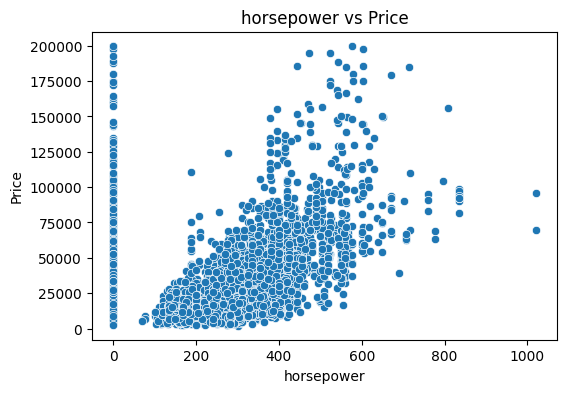

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for enhanced visualization
import seaborn as sns

# Create a figure with a specific size (width=6, height=4)
plt.figure(figsize=(6,4))

# Create a scatter plot of mileage vs price
sns.scatterplot(x=df_encoded["horsepower"], y=df_encoded["price"])

# Set the title of the plot
plt.title("horsepower vs Price")

# Label for x-axis (car mileage)
plt.xlabel("horsepower")

# Label for y-axis (car price)
plt.ylabel("Price")

# Display the plot
plt.show()

### 2.   `Car Age` vs `Price`

This plot illustrates how the `price` of a car is affected by its `age`.

To analyze whether older cars tend to have lower prices.

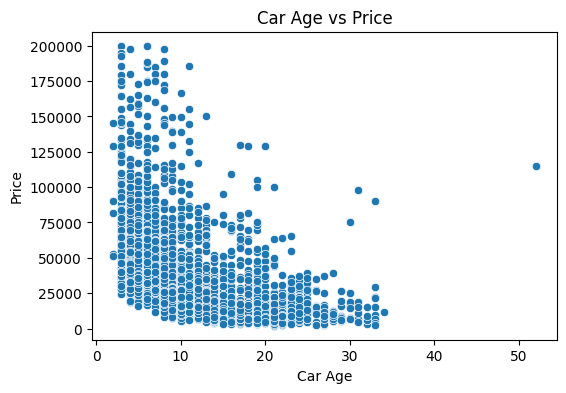

In [ ]:
# Create a figure with a specific size (width=6, height=4)
plt.figure(figsize=(6,4))

# Create a scatter plot of car age vs price
sns.scatterplot(x=df_encoded["car_age"], y=df_encoded["price"])

# Set the title of the plot
plt.title("Car Age vs Price")

# Label for x-axis (age of the car)
plt.xlabel("Car Age")

# Label for y-axis (car price)
plt.ylabel("Price")

# Display the plot
plt.show()

### 3.   `Engine Size` vs `Price`

This plot shows the relationship between `engine size` and car `price`.

To determine whether cars with larger engines tend to be more expensive.

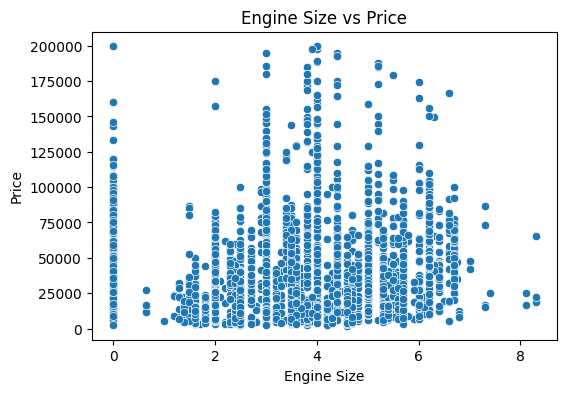

In [ ]:
# Create a figure with a specific size (width=6, height=4)
plt.figure(figsize=(6,4))

# Create a scatter plot of engine size vs price
sns.scatterplot(x=df_encoded["engine_size"], y=df_encoded["price"])

# Set the title of the plot
plt.title("Engine Size vs Price")

# Label for x-axis (engine size)
plt.xlabel("Engine Size")

# Label for y-axis (car price)
plt.ylabel("Price")

# Display the plot
plt.show()

In this stage, exploratory data analysis `EDA` was performed to visualize the relationships between important features and the target variable `price`. Scatter plots were used to analyze the effect of `horsepower`, `car_age`, and `engine_size` on car prices. The results showed that `car_age` have a negative relationship with price, while `engine_size` has a positive relationship. These visualizations helped in understanding the data before building machine learning models.

## Train-Test Split and Scaling

---



## 🔹 Step 17: Train-Test Split



The dataset is divided into two parts: training and testing.
The training set `80%` is used to train the model, while the testing set `20%` is used to evaluate its performance on unseen data.
This helps ensure that the model generalizes well and does not simply memorize the training data.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# X represents the input features (all columns except "price")
X = df_encoded.drop("price", axis=1)

# y represents the target variable (the value we want to predict: car price)
y = df_encoded["price"]

# Divide the data into training and testing sets
# test_size=0.2 → 20% of the data is used for testing, 80% for training
# random_state=42 → ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

This step allows the model to learn from one portion of the data and be tested on unseen data, which helps evaluate its performance accurately.

## 🔹 Step 18: Feature Scaling

$$
Xscaled = \frac{x - \mu}{\sigma}
$$

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Select numerical columns only
num_cols = ["milage", "engine_size", "car_age", "horsepower"]

# Make sure numerical columns are float before scaling
X_train[num_cols] = X_train[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

# Fit on training data and transform both train and test
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

`StandardScaler` = centered around 0, not bounded

In this step, numerical features were scaled using `StandardScaler`. This method standardizes the data by removing the mean and scaling to unit variance.

Scaling was applied only to numerical features such as `milage`, `engine_size`, `car_age` and `horsepower`.

Feature scaling ensures that all numerical features are on the same scale, which improves the performance of models like Linear Regression.

## 🔹 Step 19: Model Training, Evaluation and Visualization

---



## MODEL 1: Linear Regression

### 🔹 Training

A `Linear Regression` model was created and trained using the training data.

`Linear Regression` assumes that there is a linear relationship between the input features and the target variable.

This model is used as a baseline model to compare with more advanced models later.

In [ ]:
# Importing the model training function
from sklearn.linear_model import LinearRegression

# Initialize a Linear Regression model
lr_model = LinearRegression()

# Train the model with the training data
lr_model.fit(X_train, y_train)

LinearRegression()

### 🔹 Prediction

After training the model, it was used to predict the car prices for the test dataset.

This step allows us to compare the predicted prices with the actual prices and evaluate the model performance.

In [ ]:
# Make predictions using the trained model
lr_pred = lr_model.predict(X_test)

### 🔹 Evaluation

Three evaluation metrics were used:

* `MAE` (Mean Absolute Error): Measures the average absolute difference between actual and predicted values.
* `MSE` (Mean Squared Error): Measures the average squared difference between actual and predicted values.
* `RMSE` (Root Mean Squared Error): Measures the standard deviation of prediction errors in the original unit.
* `R² Score`: Measures how well the model explains the variation in the data.

These metrics help us understand the accuracy and reliability of the model.

In [ ]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics on original scale
# MAE: average absolute difference between predicted and actual values
lr_mae = mean_absolute_error(y_test, lr_pred)

# MSE: Mean squared error
lr_mse = mean_squared_error(y_test, lr_pred)

# RMSE: square root of mean squared error (penalizes large errors more)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# R2: proportion of variance explained by the model (goodness of fit)
lr_r2 = r2_score(y_test, lr_pred)

# Print results
print("Linear Regression MAE:", lr_mae)
print("Linear Regression MSE:", lr_mse)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression MAE: 8823.434179991867
Linear Regression MSE: 210937222.88670108
Linear Regression RMSE: 14523.678008228531
Linear Regression R2: 0.7445882393995138


### Important❗❗

The performance of the Linear Regression model **(and the other models as well)** improved significantly after removing outliers. The `R²` score increased from approximately `0.066` to `0.744`, indicating that the model is now able to explain a much larger portion of the variance in car prices.

### 🔹 Visualization

This line plot compares the actual prices and the predicted prices for the first 50 test samples.

It helps visualize how close the `Linear Regression` predictions are to the real car prices.

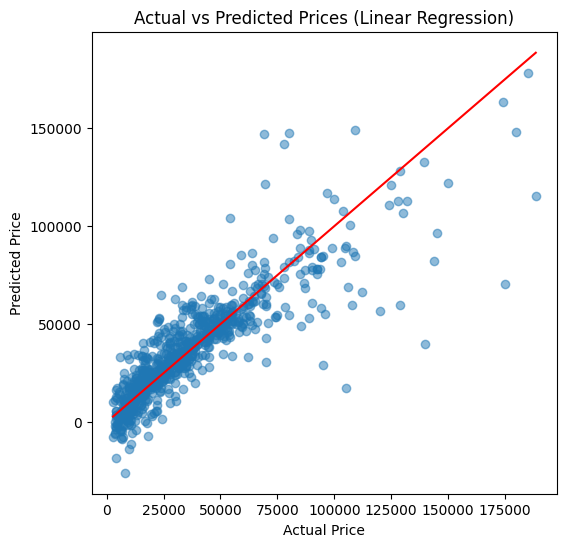

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a new figure with fixed size
plt.figure(figsize=(6,6))

# Scatter plot:
# x-axis → actual prices
# y-axis → predicted prices
# alpha → controls transparency (helps visualize dense points)
plt.scatter(y_test, lr_pred, alpha=0.5)

# Plot ideal prediction line (perfect model)
# This line represents where predicted = actual
plt.plot(
    [y_test.min(), y_test.max()],  # x values range
    [y_test.min(), y_test.max()],  # y values range
    color='red'
)

# Label x-axis
plt.xlabel("Actual Price")

# Label y-axis
plt.ylabel("Predicted Price")

# Title of the plot
plt.title("Actual vs Predicted Prices (Linear Regression)")

# Display the plot
plt.show()

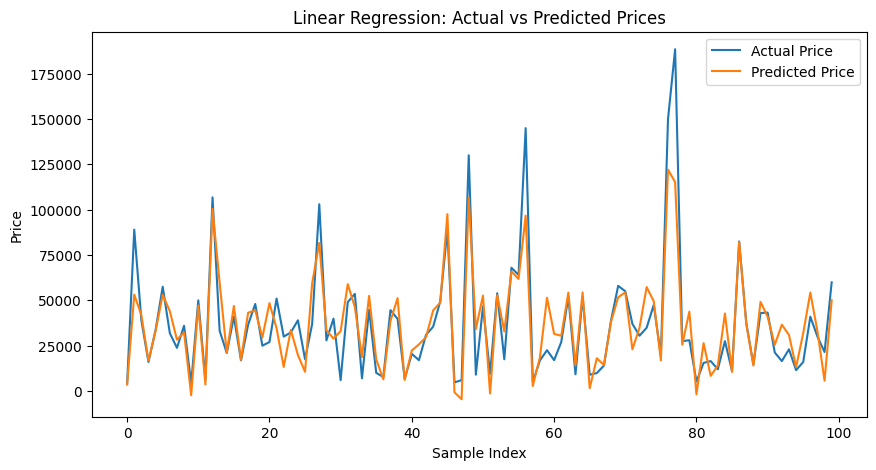

In [ ]:
# Create a new figure with a specific size
plt.figure(figsize=(10,5))

# Plot actual prices (converted back to original scale)
plt.plot(y_test.values[:100], label="Actual Price")

# Plot predicted prices from Random Forest
plt.plot(lr_pred[:100], label="Predicted Price")

# Set the title of the plot
plt.title("Linear Regression: Actual vs Predicted Prices")

# Label for x-axis (sample index)
plt.xlabel("Sample Index")

# Label for y-axis (price)
plt.ylabel("Price")

# Show legend
plt.legend()

# Display the plot
plt.show()

### 🔹 Linear Regression Problem

The Linear Regression model showed weak performance, which indicates that the relationship between the input features and car price **is not purely linear**. Therefore, more advanced models are required to capture the complexity of the data.

## MODEL 2: Random Forest

### 🔹 Training

A `Random Forest` Regressor model was created and trained using the training data.

`Random Forest` works by building **multiple decision trees** and averaging their predictions, which usually leads to better accuracy and less `overfitting` than a single **decision tree**.

This model is used because it can capture more complex and non-linear relationships in the data.

In [ ]:
# Import Random Forest model
from sklearn.ensemble import RandomForestRegressor

# Initialize a Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,      # more trees → better stability
    random_state=42,       # ensures reproducibility
)

# Train the model on training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### 🔹 Prediction

The trained Random Forest model was used to predict car prices for the test data.

To compare predicted prices with actual prices and evaluate the model.

In [ ]:
# Generate predictions using the Random Forest model
rf_pred = rf_model.predict(X_test)

### 🔹 Evaluation

The same evaluation metrics were used to measure the performance of the Random Forest model:

*   `MAE`
*   `MSE`
*   `RMSE`
*   `R² Score`

Using the same metrics allows a fair comparison between models.

In [ ]:
# Calculate Mean Absolute Error (average absolute difference between actual and predicted values)
rf_mae = mean_absolute_error(y_test, rf_pred)

# MSE: Mean squared error
rf_mse = mean_squared_error(y_test, rf_pred)

# Calculate Root Mean Squared Error (penalizes larger errors more than MAE)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# Calculate R-squared (proportion of variance explained by the model)
rf_r2 = r2_score(y_test, rf_pred)

# Print the evaluation results
print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)


Random Forest MAE: 7339.096073697585
Random Forest MSE: 164250183.45351464
Random Forest RMSE: 12816.012775177569
Random Forest R2: 0.8011188923381815


### 🔹 Visualization

This line plot compares the actual prices and the predicted prices for the first 50 test samples.

It helps visualize how close the `Random Forest` predictions are to the real car prices.

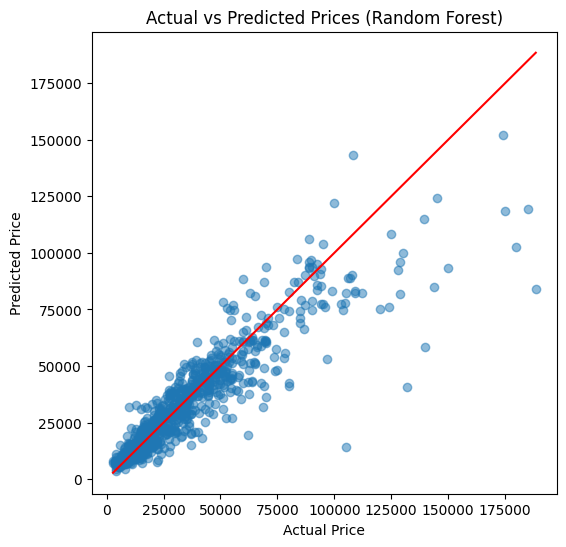

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a new figure with fixed size
plt.figure(figsize=(6,6))

# Scatter plot:
# x-axis → actual prices
# y-axis → predicted prices
# alpha → controls transparency (helps visualize dense points)
plt.scatter(y_test, rf_pred, alpha=0.5)

# Plot ideal prediction line (perfect model)
# This line represents where predicted = actual
plt.plot(
    [y_test.min(), y_test.max()],  # x values range
    [y_test.min(), y_test.max()],  # y values range
    color='red'
)

# Label x-axis
plt.xlabel("Actual Price")

# Label y-axis
plt.ylabel("Predicted Price")

# Title of the plot
plt.title("Actual vs Predicted Prices (Random Forest)")

# Display the plot
plt.show()

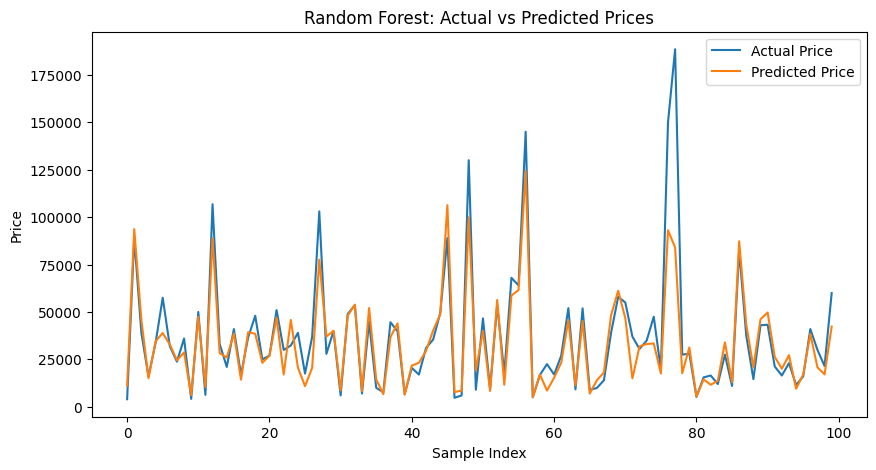

In [ ]:
# Create a new figure with a specific size
plt.figure(figsize=(10,5))

# Plot actual prices (converted back to original scale)
plt.plot(y_test.values[:100], label="Actual Price")

# Plot predicted prices from Random Forest
plt.plot(rf_pred[:100], label="Predicted Price")

# Set the title of the plot
plt.title("Random Forest: Actual vs Predicted Prices")

# Label for x-axis (sample index)
plt.xlabel("Sample Index")

# Label for y-axis (price)
plt.ylabel("Price")

# Show legend
plt.legend()

# Display the plot
plt.show()

## Model 3: XGBoost

### 🔹 Training

An `XGBoost` Regressor model was created and trained using the training data.

`XGBoost` is a boosting algorithm that builds models sequentially, where each new model tries to correct the errors of the previous one.

This model is used because it is powerful, efficient, and often achieves very high accuracy in regression tasks.

In [ ]:
from xgboost import XGBRegressor  # Import XGBoost regression model

# Initialize a XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,       # number of trees
    learning_rate=0.2,     # learning speed
    max_depth=6,            # depth of each tree
    random_state=42         # ensures reproducibility
)

# Train the model on training data
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

### 🔹 Prediction

The trained `XGBoost` model was used to predict car prices for the test data.

To evaluate the model by comparing the predicted values with the actual values.

In [ ]:
# Generate predictions
xgb_pred = xgb_model.predict(X_test)

### 🔹 Evaluation

The performance of `XGBoost` was evaluated using the same regression metrics:

*   `MAE`
*   `MSE`
*   `RMSE`
*   `R² Score`

In [ ]:
# Evaluate the model using original scale values

# average absolute error
xgb_mae = mean_absolute_error(y_test, xgb_pred)

# MSE: Mean squared error
xgb_mse = mean_squared_error(y_test, xgb_pred)

# penalizes large errors
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

# goodness of fit
xgb_r2 = r2_score(y_test, xgb_pred)

# Print the evaluation results
print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 6695.57177734375
XGBoost MSE: 113720304.0
XGBoost RMSE: 10663.972243024642
XGBoost R2: 0.8623026013374329


### 🔹 Visualization

This line plot compares the actual prices and the predicted prices of the `XGBoost` model for the first 50 test samples.

This plot helps visually assess the prediction quality of the model.

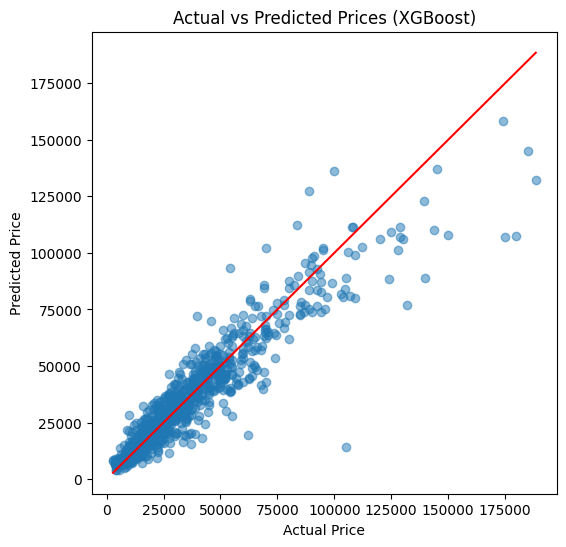

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a new figure with fixed size
plt.figure(figsize=(6,6))

# Scatter plot:
# x-axis → actual prices
# y-axis → predicted prices
# alpha → controls transparency (helps visualize dense points)
plt.scatter(y_test, xgb_pred, alpha=0.5)

# Plot ideal prediction line (perfect model)
# This line represents where predicted = actual
plt.plot(
    [y_test.min(), y_test.max()],  # x values range
    [y_test.min(), y_test.max()],  # y values range
    color='red'
)

# Label x-axis
plt.xlabel("Actual Price")

# Label y-axis
plt.ylabel("Predicted Price")

# Title of the plot
plt.title("Actual vs Predicted Prices (XGBoost)")

# Display the plot
plt.show()

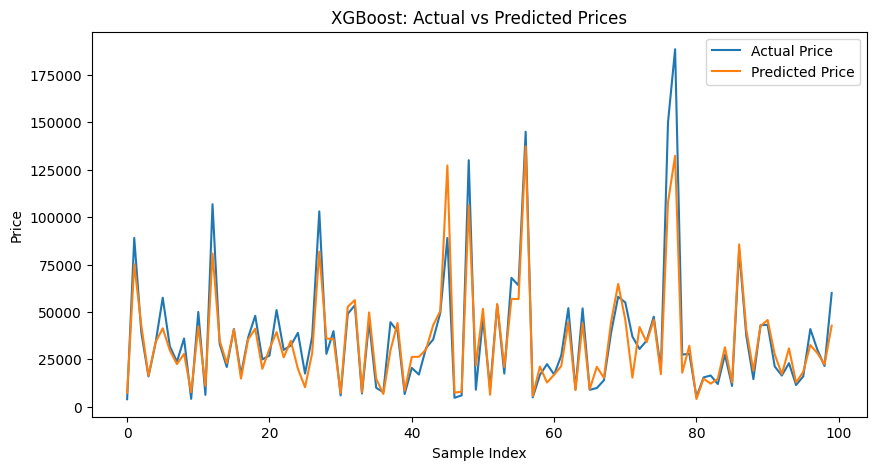

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a new figure with a specific size
plt.figure(figsize=(10,5))

# Plot actual prices for the first 100 samples
plt.plot(y_test.values[:100], label="Actual Price")

# Plot predicted prices from XGBoost for the first 100 samples
plt.plot(xgb_pred[:100], label="Predicted Price")

# Set the title of the plot
plt.title("XGBoost: Actual vs Predicted Prices")

# Label x-axis
plt.xlabel("Sample Index")

# Label y-axis
plt.ylabel("Price")

# Show legend
plt.legend()

# Display the plot
plt.show()

### 🔹 SHAP Feature Importance Plot
This step creates a `SHAP` bar chart to show the most important features used by the `XGBoost` model when predicting car prices.

`SHAP` values explain how much each feature contributes to the model’s predictions. The plot displays the top 20 features ranked by their average impact on the predicted price.

The purpose of this visualization is to understand which variables, such as `mileage`, `car_age`, `engine_size`, or `brand`, have the strongest influence on the model's decisions. Features with larger bars are more important to the prediction process.

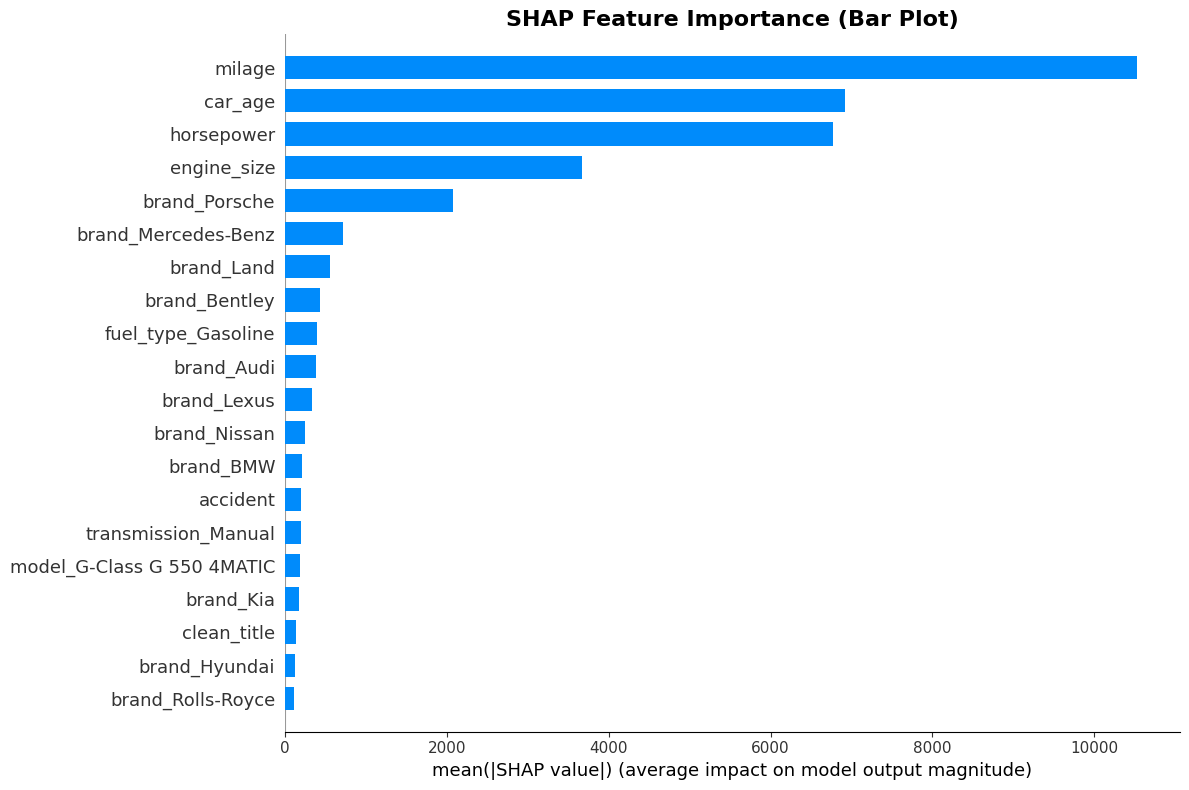

In [ ]:
# Import the SHAP library for model explainability
import shap

# Import Matplotlib for customizing and displaying the plot
import matplotlib.pyplot as plt

# Create a SHAP explainer specifically for tree-based models
# (XGBoost, Random Forest, LightGBM, etc.)
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test dataset
# SHAP values show how much each feature contributes
# to increasing or decreasing the predicted price
shap_values = explainer.shap_values(X_test)

# Create a SHAP bar plot
# This plot displays the average absolute SHAP value
# for each feature, which represents overall importance
shap.summary_plot(
    shap_values,          # Computed SHAP values
    X_test,               # Input features corresponding to SHAP values
    plot_type="bar",      # Use bar chart instead of beeswarm plot
    max_display=20,       # Show the top 20 most important features
    plot_size=(12, 8),    # Set the width and height of the plot
    show=False            # Delay displaying so we can add a custom title
)

# Add a custom title to the plot
plt.title(
    "SHAP Feature Importance (Bar Plot)",
    fontsize=16,
    fontweight="bold"
)

# Adjust the layout to prevent overlapping labels
plt.tight_layout()

# Display the final plot
plt.show()

## 🔹 Compare the Three Models

---



In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "MSE": [lr_mse, rf_mse, xgb_mse],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R2": [lr_r2, rf_r2, xgb_r2]
})

print(results)

               Model          MAE           MSE          RMSE        R2
0  Linear Regression  8823.434180  2.109372e+08  14523.678008  0.744588
1      Random Forest  7339.096074  1.642502e+08  12816.012775  0.801119
2            XGBoost  6695.571777  1.137203e+08  10663.972243  0.862303


A comparison table was created to summarize the performance of the three models using the same evaluation metrics.


This makes it easier to identify the best-performing model.

## 🔹 Visualize Model Comparison

---

A bar chart was created to compare the `R² score` of the three models.

This visualization provides a clear comparison of model accuracy and helps identify the strongest model.

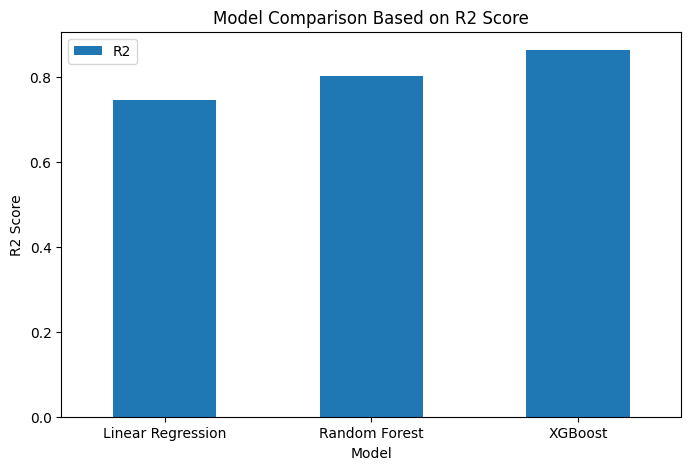

In [ ]:
import matplotlib.pyplot as plt  # Import matplotlib for plotting

# Create a bar plot comparing models based on R2 score
results.set_index("Model")[["R2"]].plot(kind="bar", figsize=(8,5))

# Set the title of the plot
plt.title("Model Comparison Based on R2 Score")

# Label for x-axis (model names)
plt.xlabel("Model")

# Label for y-axis (R2 score values)
plt.ylabel("R2 Score")

# Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# Display the plot
plt.show()

## 🔹 Final Evaluation Discussion

---

The evaluation results show that `XGBoost` outperformed both `Linear Regression` and `Random Forest`, achieving the highest accuracy. This indicates that car price prediction is a complex, non-linear problem, where advanced ensemble models perform better. Data preprocessing and feature engineering played a key role in improving model performance.

## 🔹 Examples

---



In [ ]:
# Create sample cars (raw format before encoding)
new_data = pd.DataFrame([
    {
        "brand": "Toyota",
        "milage": 50000,
        "fuel_type": "Gasoline",
        "transmission": "Automatic",
        "accident": 0,
        "clean_title": 1,
        "engine_size": 2.5,
        "horsepower": 200,
        "car_age": 5,
        "is_electric": 0,
        "is_hybrid": 0
    },
    {
        "brand": "BMW",
        "milage": 30000,
        "fuel_type": "Gasoline",
        "transmission": "Automatic",
        "accident": 0,
        "clean_title": 1,
        "engine_size": 3.0,
        "horsepower": 300,
        "car_age": 3,
        "is_electric": 0,
        "is_hybrid": 0
    },
    {
        "brand": "Tesla",
        "milage": 20000,
        "fuel_type": "Electric",
        "transmission": "Automatic",
        "accident": 0,
        "clean_title": 1,
        "engine_size": 0,
        "horsepower": 0,
        "car_age": 2,
        "is_electric": 1,
        "is_hybrid": 0
    }
])

In [ ]:
# Convert to same format as training data
new_data_encoded = pd.get_dummies(new_data)

# Align columns with training data
new_data_encoded = new_data_encoded.reindex(columns=X.columns, fill_value=0)

In [ ]:
# Convert numerical columns to float before scaling
new_data_encoded[num_cols] = new_data_encoded[num_cols].astype(float)

# Apply the same scaler used in training
new_data_encoded[num_cols] = scaler.transform(new_data_encoded[num_cols])

In [ ]:
# Linear Regression
lr_pred = lr_model.predict(new_data_encoded)

# Random Forest
rf_pred = rf_model.predict(new_data_encoded)

# XGBoost
xgb_pred = xgb_model.predict(new_data_encoded)

In [ ]:
results = pd.DataFrame({
    "Car": ["Toyota", "BMW", "Tesla"],
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
})

print(results)

      Car  Linear Regression  Random Forest       XGBoost
0  Toyota       42152.613252       26822.91  26747.048828
1     BMW       55563.182982       53773.17  48943.816406
2   Tesla       73105.764451       42124.29  41662.230469


New sample data was created and passed through the same preprocessing pipeline used during training. Predictions were generated using all trained models and converted back to the original price scale.

## 🔹 Interactive Input Code

---



In [ ]:
# Take input from user
brand = input("Enter brand (e.g., Toyota): ")
milage = float(input("Enter milage: "))
engine_size = float(input("Enter engine size (L): "))
horsepower = float(input("Enter horsepower: "))
car_age = float(input("Enter car age: "))
is_electric = float(input("Electric? (1 yes / 0 no): "))
is_hybrid = float(input("Hybrid? (1 yes / 0 no): "))
accident = float(input("Accident? (1 yes / 0 no): "))
clean_title = float(input("Clean title? (1 yes / 0 no): "))

# Create dataframe
new_car = pd.DataFrame([{
    "brand": brand,
    "milage": milage,
    "engine_size": engine_size,
    "horsepower": horsepower,
    "car_age": car_age,
    "is_electric": is_electric,
    "is_hybrid": is_hybrid,
    "accident": accident,
    "clean_title": clean_title
}])

# Encoding
new_car = pd.get_dummies(new_car)
new_car = new_car.reindex(columns=X.columns, fill_value=0)

# Convert numerical columns to float before scaling
new_car[num_cols] = new_car[num_cols].astype(float)

# Scaling
new_car[num_cols] = scaler.transform(new_car[num_cols])

# Prediction (XGBoost best model)
pred_price = xgb_model.predict(new_car)

print("Predicted Price:", round(pred_price[0], 2))

Enter brand (e.g., Toyota): BMW
Enter milage: 10000
Enter engine size (L): 3.5
Enter horsepower: 300
Enter car age: 3
Electric? (1 yes / 0 no): 0
Hybrid? (1 yes / 0 no): 1
Accident? (1 yes / 0 no): 0
Clean title? (1 yes / 0 no): 1
Predicted Price: 56508.64
